In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch
import numpy as np
sys.path.append(os.path.abspath('../scripts'))
from supporting.load_data import load_data, build_data_loaders, x_scale, y_scale, y_unscale
from sklearn import metrics
from torch import nn, optim
import torch.nn.functional as F


In [2]:
def get_device():
    ''' function to get the device the NN is running on, CPU or GPU
    '''
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else: 
        device = torch.device("cpu")
        
    return device


In [3]:
# config["data_dir"] = "/scratch/akula.ha/dataset"


In [4]:
torch.set_default_dtype(torch.float64)


In [5]:
class MyDataset(torch.utils.data.Dataset):
    '''Class to convert dataframe to torch tensor'''
    def __init__(self, x, y, config):
        x = x.copy(deep=True)
        y = y.copy(deep=True)

        # Vectorized scaling (if applicable)
        x['x1'] = x_scale(x['x1'])  # Or use apply if x_scale isn't vectorized

        # Number of targets
        config['n_targets'] = y.shape[1]

        for column in y.columns:
            y[column] = y[column].apply(y_scale)

        device = get_device()
        self.x = torch.tensor(x.values, dtype=torch.float64).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float64).reshape(-1, config['n_targets']).to(device)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# df, spark = load_data(config)

# x_cols = ['x1', 'x2', 'x3', 'x4']
# y_cols = config["var_y"]
# x_train = df["train"][x_cols]
# y_train = df["train"][y_cols]
# x_val = df["validate"][x_cols]
# y_val = df["validate"][y_cols]
# x_test = df["test"][x_cols]
# y_test = df["test"][y_cols]

# train_dataset = MyDataset(x_train, y_train, config)
# val_dataset   = MyDataset(x_val, y_val, config)
# test_dataset  = MyDataset(x_test, y_test, config)

# # load the data into torch tensor batches
# batch_size = config["batch_size"]
# numworkers = 4 if get_device().type == 'cpu' else 0

# # train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
# # val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
# # test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=numworkers, drop_last=True)

In [6]:
# model_path = weights_path # "/home/hakula/qqzz4l-NN/models/skip-mini_ff414e9e_30_12_5/ff414e9e.best_weights.pt"

In [18]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

def safe_mape(y_true, y_pred, eps=1e-6):
    """
    Mean Absolute Percentage Error with denominator guard.
    Adds eps to denominator to avoid blow-up near zero.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))


def _percent_delta(y_true, y_pred, eps=1e-6):
    """
    Percentage delta with epsilon guard:
    (y_pred - y_true) / (y_true + eps) * 100
    """
    return (y_pred - y_true) / (y_true + eps) * 100.0


def _plot_error_histograms(delta_matrix, labels, cutoff=5, title="Error Histogram Overlay"):
    """Overlay histogram for each target column in delta_matrix."""
    plt.figure(figsize=(8, 5))
    for j, name in enumerate(labels):
        col = delta_matrix[:, j]
        m = np.isfinite(col)
        if cutoff is not None:
            m &= (np.abs(col) < cutoff)
        data = col[m]
        if data.size == 0:
            continue
        plt.hist(data, bins=100, histtype='step', label=name, density=True)
    plt.grid(True, linestyle='dotted', alpha=0.5)
    plt.xlabel(r'$\delta$ (%)')
    plt.ylabel('pdf')
    plt.title(title)
    plt.legend()
    # plt.show()
    plt.close()


def evaluate_model(model, dataloader, device, output_dir, config):
    """
    Evaluate a trained model and save:
      - metrics.json (scaled & unscaled)
      - hist_unscaled_overlay.png, hist_scaled_overlay.png
    Requires a globally available scalar y_unscale(y: float) -> float.
    """
    os.makedirs(output_dir, exist_ok=True)

    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            pred = model(xb).cpu()
            all_preds.append(pred)
            all_targets.append(yb.cpu())

    y_true = torch.cat(all_targets, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()

    y_names = config["var_y"]
    assert y_true.ndim == 2 and y_true.shape[1] == len(y_names), \
        "Mismatch between targets array shape and config['var_y']"

    # -------- Scaled metrics --------
    scaled = {}
    overall_mape = mean_absolute_percentage_error(y_true, y_pred)
    overall_r2   = r2_score(y_true, y_pred)
    overall_abs  = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
    scaled["overall"] = {"MAPE": float(overall_mape), "R2": float(overall_r2), "abs_score": float(overall_abs)}
    scaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j = mean_absolute_percentage_error(y_true[:, j], y_pred[:, j])
        r2_j   = r2_score(y_true[:, j], y_pred[:, j])
        abs_j  = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
        scaled["per_target"][name] = {"MAPE": float(mape_j), "R2": float(r2_j), "abs_score": float(abs_j)}

    # -------- Unscaled metrics --------
    # Your y_unscale is scalar-only; vectorize it.
    y_unscale_vec = np.vectorize(y_unscale)
    y_true_un = y_unscale_vec(y_true)
    y_pred_un = y_unscale_vec(y_pred)

    unscaled = {}
    overall_mape_un = mean_absolute_percentage_error(y_true_un, y_pred_un)
    overall_r2_un   = r2_score(y_true_un, y_pred_un)
    overall_abs_un  = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
    unscaled["overall"] = {"MAPE": float(overall_mape_un), "R2": float(overall_r2_un), "abs_score": float(overall_abs_un)}
    unscaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j_un = mean_absolute_percentage_error(y_true_un[:, j], y_pred_un[:, j])
        r2_j_un   = r2_score(y_true_un[:, j], y_pred_un[:, j])
        abs_j_un  = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
        unscaled["per_target"][name] = {"MAPE": float(mape_j_un), "R2": float(r2_j_un), "abs_score": float(abs_j_un)}

    # -------- Deltas (arrays, no DataFrame) --------
    scaled_delta   = _percent_delta(y_true,    y_pred)
    unscaled_delta = _percent_delta(y_true_un, y_pred_un)

    # -------- Save metrics JSON --------
    metrics = {"scaled": scaled, "unscaled": unscaled, "meta": {"num_samples": int(y_true.shape[0]), "targets": y_names}}
    out_path = os.path.join(output_dir, "metrics.json")
    with open(out_path, "w") as f:
        json.dump(metrics, f, indent=2)

    # -------- Save plots (overlay style) --------
    _save_error_plots_from_arrays(
        unscaled_delta, y_names, os.path.join(output_dir, "hist_unscaled_overlay.png"), cutoff=5
    )
    _save_error_plots_from_arrays(
        scaled_delta, y_names, os.path.join(output_dir, "hist_scaled_overlay.png"), cutoff=5
    )

    # Console summary
    print("\n=== Evaluation (SCALED) ===")
    print(f"Overall MAPE      : {scaled['overall']['MAPE']:.6f}")
    print(f"Overall R2        : {scaled['overall']['R2']:.6f}")
    print(f"Overall abs_score : {scaled['overall']['abs_score']:.6f}")
    for n, v in scaled["per_target"].items():
        print(f"{n} - MAPE: {v['MAPE']:.6f} | R2: {v['R2']:.6f} | abs_score: {v['abs_score']:.6f}")

    print("\n=== Evaluation (UNSCALED) ===")
    print(f"Overall MAPE      : {unscaled['overall']['MAPE']:.6f}")
    print(f"Overall R2        : {unscaled['overall']['R2']:.6f}")
    print(f"Overall abs_score : {unscaled['overall']['abs_score']:.6f}")
    for n, v in unscaled["per_target"].items():
        print(f"{n} - MAPE: {v['MAPE']:.6f} | R2: {v['R2']:.6f} | abs_score: {v['abs_score']:.6f}")

    print(f"\nSaved metrics to: {out_path}")
    print("Saved histograms to:",
          os.path.join(output_dir, "hist_unscaled_overlay.png"), "and",
          os.path.join(output_dir, "hist_scaled_overlay.png"))
    
    plot_losses_from_output_dir(output_dir)

    return {
        "metrics": metrics,
        "paths": {
            "metrics_json": out_path,
            "hist_unscaled": os.path.join(output_dir, "hist_unscaled_overlay.png"),
            "hist_scaled": os.path.join(output_dir, "hist_scaled_overlay.png"),
            "loss_plot": os.path.join(output_dir, "loss_plot.png"),
            "loss_plot_loglog": os.path.join(output_dir, "loss_plot_loglog.png"),
        }
    }

import copy

# def ensemble_from_checkpoints(model, checkpoint_paths, dataloader, device, config, eps=1e-6):
#     """
#     Evaluate an ensemble by averaging predictions from multiple checkpoints.
#     """
#     assert len(checkpoint_paths) > 0, "No checkpoints provided for ensemble"

#     all_preds, all_targets = [], []
#     model.eval()

#     # AFTER (load once outside batch loop — fast)
#     models = []
#     for path in checkpoint_paths:
#         state = torch.load(path, map_location=device)
#         model.load_state_dict(state)
#         models.append(copy.deepcopy(model))
#         models[-1].eval()

#     with torch.no_grad():
#         for xb, yb in dataloader:
#             xb = xb.to(device)
#             preds_per_ckpt = [m(xb).cpu() for m in models]

#             mean_pred = torch.stack(preds_per_ckpt, dim=0).mean(dim=0)
#             all_preds.append(mean_pred)
#             all_targets.append(yb.cpu())

#     y_true = torch.cat(all_targets, dim=0).numpy()
#     y_pred = torch.cat(all_preds, dim=0).numpy()
#     y_names = config["var_y"]

#     scaled = {}
#     overall_mape = safe_mape(y_true, y_pred, eps=eps)
#     overall_r2 = r2_score(y_true, y_pred)
#     overall_abs = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
#     scaled["overall"] = {"MAPE": overall_mape, "R2": overall_r2, "abs_score": overall_abs}
#     scaled["per_target"] = {}
#     for j, name in enumerate(y_names):
#         mape_j = safe_mape(y_true[:, j], y_pred[:, j], eps=eps)
#         r2_j = r2_score(y_true[:, j], y_pred[:, j])
#         abs_j = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
#         scaled["per_target"][name] = {"MAPE": mape_j, "R2": r2_j, "abs_score": abs_j}

#     y_unscale_vec = np.vectorize(y_unscale)
#     y_true_un = y_unscale_vec(y_true)
#     y_pred_un = y_unscale_vec(y_pred)

#     unscaled = {}
#     overall_mape_un = safe_mape(y_true_un, y_pred_un, eps=eps)
#     overall_r2_un = r2_score(y_true_un, y_pred_un)
#     overall_abs_un = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
#     unscaled["overall"] = {"MAPE": overall_mape_un, "R2": overall_r2_un, "abs_score": overall_abs_un}
#     unscaled["per_target"] = {}
#     for j, name in enumerate(y_names):
#         mape_j_un = safe_mape(y_true_un[:, j], y_pred_un[:, j], eps=eps)
#         r2_j_un = r2_score(y_true_un[:, j], y_pred_un[:, j])
#         abs_j_un = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
#         unscaled["per_target"][name] = {"MAPE": mape_j_un, "R2": r2_j_un, "abs_score": abs_j_un}

#     print("\n=== Ensemble Evaluation (SCALED) ===")
#     print(f"Overall MAPE: {scaled['overall']['MAPE']:.6f}")
#     print(f"Overall R2  : {scaled['overall']['R2']:.6f}")
#     print(f"Overall Abs : {scaled['overall']['abs_score']:.6f}")
#     for n, v in scaled["per_target"].items():
#         print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

#     print("\n=== Ensemble Evaluation (UNSCALED) ===")
#     print(f"Overall MAPE: {unscaled['overall']['MAPE']:.6f}")
#     print(f"Overall R2  : {unscaled['overall']['R2']:.6f}")
#     print(f"Overall Abs : {unscaled['overall']['abs_score']:.6f}")
#     for n, v in unscaled["per_target"].items():
#         print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

#     scaled_delta = _percent_delta(y_true, y_pred, eps=eps)
#     unscaled_delta = _percent_delta(y_true_un, y_pred_un, eps=eps)
#     _plot_error_histograms(unscaled_delta, y_names, cutoff=5, title="Unscaled Ensemble Errors")
#     _plot_error_histograms(scaled_delta, y_names, cutoff=5, title="Scaled Ensemble Errors")

#     return scaled, unscaled


# def run_ensemble_evaluation(test_df, checkpoint_paths, config, dataloader, eps=0):
#     """
#     Build a model from config, evaluate an ensemble of checkpoints, and return results.
#     """
#     print(f"\n{'#' * 80}")
#     print(f"Starting ensemble evaluation for targets: {config['var_y']}")
#     print(f"Using {len(checkpoint_paths)} checkpoints")
#     print(f"{'#' * 80}")

#     width = config['width']
#     depth = config['depth']
#     n_skip_layers = config['skip_block_layers']
#     activation = config['activation']

#     ensemble_model = SkipModel(
#         config["input_shape"],
#         width,
#         depth,
#         n_skip_layers,
#         len(config["var_y"]),
#         activation,
#     )
#     ensemble_model.to(device=get_device())

#     scaled_metrics, unscaled_metrics = ensemble_from_checkpoints(
#         model=ensemble_model,
#         checkpoint_paths=checkpoint_paths,
#         dataloader=dataloader,
#         device=get_device(),
#         config=config,
#         eps=eps,
#     )

#     return {
#         "checkpoint_paths": checkpoint_paths,
#         "config": config,
#         "filtered_test_df": test_df.copy(deep=True),
#         "scaled_metrics": scaled_metrics,
#         "unscaled_metrics": unscaled_metrics,
#     }

def ensemble_from_checkpoints(model, checkpoint_paths, dataloader, device, config, output_dir, eps=1e-6):
    assert len(checkpoint_paths) > 0, "No checkpoints provided for ensemble"

    all_preds, all_targets = [], []
    model.eval()

    models = []
    for path in checkpoint_paths:
        state = torch.load(path, map_location=device)
        model.load_state_dict(state)
        models.append(copy.deepcopy(model))
        models[-1].eval()

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            preds_per_ckpt = [m(xb).cpu() for m in models]
            mean_pred = torch.stack(preds_per_ckpt, dim=0).mean(dim=0)
            all_preds.append(mean_pred)
            all_targets.append(yb.cpu())

    y_true = torch.cat(all_targets, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()
    y_names = config["var_y"]

    scaled = {}
    overall_mape = safe_mape(y_true, y_pred, eps=eps)
    overall_r2 = r2_score(y_true, y_pred)
    overall_abs = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
    scaled["overall"] = {"MAPE": overall_mape, "R2": overall_r2, "abs_score": overall_abs}
    scaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j = safe_mape(y_true[:, j], y_pred[:, j], eps=eps)
        r2_j = r2_score(y_true[:, j], y_pred[:, j])
        abs_j = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
        scaled["per_target"][name] = {"MAPE": mape_j, "R2": r2_j, "abs_score": abs_j}

    y_unscale_vec = np.vectorize(y_unscale)
    y_true_un = y_unscale_vec(y_true)
    y_pred_un = y_unscale_vec(y_pred)

    unscaled = {}
    overall_mape_un = safe_mape(y_true_un, y_pred_un, eps=eps)
    overall_r2_un = r2_score(y_true_un, y_pred_un)
    overall_abs_un = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
    unscaled["overall"] = {"MAPE": overall_mape_un, "R2": overall_r2_un, "abs_score": overall_abs_un}
    unscaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j_un = safe_mape(y_true_un[:, j], y_pred_un[:, j], eps=eps)
        r2_j_un = r2_score(y_true_un[:, j], y_pred_un[:, j])
        abs_j_un = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
        unscaled["per_target"][name] = {"MAPE": mape_j_un, "R2": r2_j_un, "abs_score": abs_j_un}

    print("\n=== Ensemble Evaluation (SCALED) ===")
    print(f"Overall MAPE: {scaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {scaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {scaled['overall']['abs_score']:.6f}")
    for n, v in scaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    print("\n=== Ensemble Evaluation (UNSCALED) ===")
    print(f"Overall MAPE: {unscaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {unscaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {unscaled['overall']['abs_score']:.6f}")
    for n, v in unscaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    scaled_delta = _percent_delta(y_true, y_pred)
    unscaled_delta = _percent_delta(y_true_un, y_pred_un)

    os.makedirs(output_dir, exist_ok=True)
    _save_error_plots_from_arrays(
        unscaled_delta, y_names,
        os.path.join(output_dir, "hist_unscaled_overlay.png"), cutoff=5
    )
    _save_error_plots_from_arrays(
        scaled_delta, y_names,
        os.path.join(output_dir, "hist_scaled_overlay.png"), cutoff=5
    )

    return scaled, unscaled

def run_ensemble_evaluation(test_df, checkpoint_paths, config, dataloader, pair, eps=1e-6):
    print(f"\n{'#' * 80}")
    print(f"Starting ensemble evaluation for targets: {config['var_y']}")
    print(f"Using {len(checkpoint_paths)} checkpoints")
    print(f"{'#' * 80}")

    ensemble_output_dir = os.path.join(ARTIFACT_ROOT, f"{pair}_ensemble")

    ensemble_model = SkipModel(
        config["input_shape"],
        config["width"],
        config["depth"],
        config["skip_block_layers"],
        len(config["var_y"]),
        config["activation"],
    ).to(get_device())

    scaled_metrics, unscaled_metrics = ensemble_from_checkpoints(
        model=ensemble_model,
        checkpoint_paths=checkpoint_paths,
        dataloader=dataloader,
        device=get_device(),
        config=config,
        output_dir=ensemble_output_dir,
        eps=eps,
    )

    return {
        "checkpoint_paths": checkpoint_paths,
        "config": config,
        "filtered_test_df": test_df.copy(deep=True),
        "scaled_metrics": scaled_metrics,
        "unscaled_metrics": unscaled_metrics,
        "output_dir": ensemble_output_dir,
    }

In [19]:
def test_model(model, test_data, config):
    ''' function for testing the model
        arguments:
            model: the pytorch model to nbe trained
            test_data: the test data loader
            config: the configurations file
        returns:
            the absolute error
            the R2 score
    '''
    
    for i, data in enumerate(test_data):
        
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))
        
    
    # accuracy
    y_test = np.array(y_test).reshape(-1, config['n_targets'])
    y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
    abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
    r2_score = metrics.r2_score(y_test, y_pred)*100
    
    # save test results
    df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])
    
    # unscale the target
    scaled_cname = [s + '_scaled' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)
    for col in df_pred.columns[4:]:
        df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
    # df_pred = pd.concat([df_pred, y_test_real], axis=1)
    y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # stuff in the scaled predictions
    pred_cname = [s + '_scaled_pred' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)
    
    # stuff in the unscaled predictions
    pred_cname = [s + '_pred' for s in config['var_y']]
    for col in df_pred.columns[-config['n_targets']:]:
        df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
    # df_pred = pd.concat([df_pred, y_pred_real], axis=1)
    y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # calculate the deltas for the scaled and unscaled targets
    scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
    delta_cname = ['delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)
    
    #same the whole dataframe

    test_metrics = {}
    test_metrics['r2'] = {}
    test_metrics['abs_score'] = {}
    num_vars = len(config['var_y'])
    base_length = config['input_shape'] + num_vars
    for i in range(base_length, base_length + num_vars):
        test = df_pred.iloc[:,i].values
        pred = df_pred.iloc[:,i + 2 * num_vars].values
        test_metrics['r2'][config['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
        test_metrics['abs_score'][config['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars]).mean()
    
    test_metrics['r2']['model'] = r2_score
    test_metrics['abs_score']['model'] = abs_score
    
    return test_metrics, df_pred



In [20]:
def get_activation(activation_str):
    if activation_str == 'leaky_relu':
        return nn.LeakyReLU()
    elif activation_str == 'relu':
        return nn.ReLU()
    if activation_str == 'softplus':
        return nn.Softplus()
    if activation_str == 'swish':
        return nn.SiLU()
    if activation_str == 'sigmoid':
        return nn.Sigmoid()
    if activation_str == 'tanh':
        return nn.Tanh()
    if activation_str == 'prelu':
        return nn.PReLU()
    if activation_str == 'elu':
        return nn.ELU()

# Residual module (equivalent to 'module' in Keras)
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, width, n_skip_layers, activation='swish'):
        super().__init__()
        layers = []
        orig_in_dim = in_dim
        for _ in range(n_skip_layers - 1):
            layers.append(nn.Linear(in_dim, width))
            layers.append(get_activation(activation))
            in_dim = width
        layers.append(nn.Linear(width, orig_in_dim))  # projection back to input dim
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.net(x)

# Full model (equivalent to 'model' in Keras)
class SkipModel(nn.Module):
    def __init__(self, input_dim, width, depth, n_skip_layers, output_dim, activation='swish'):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, width),
            get_activation(activation)
        )
        self.res_blocks = nn.Sequential(*[
            ResidualBlock(in_dim=width, width=width, n_skip_layers=n_skip_layers, activation=activation) for _ in range(depth)
        ])
        self.output_layer = nn.Linear(width, output_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        return self.output_layer(x)



# Ensembling

In [21]:
def filter_test_dataframe_min_abs(df, cols, threshold=1e-8):
    import numpy as np

    df_temp = df.copy()
    mask = np.ones(len(df_temp), dtype=bool)

    for col in cols:
        x = df_temp[col]

        # Keep only rows where absolute value is NOT too small
        mask &= x.abs() > threshold  # strict AND across all columns

    return df_temp[mask]

In [22]:

# def _percent_delta(y_true, y_pred):
#     """(y_pred - y_true)/y_true * 100 with zero-guard → NaNs where denom≈0."""
# #     delta = np.full_like(y_true, np.nan, dtype=float)
# #     mask = np.abs(y_true) > 1e-12
# #     delta[mask] = (y_pred[mask] - y_true[mask]) / y_true[mask] * 100.0
# #     return delta
#     """(y_pred - y_true)/y_true * 100 without zero-guard."""
#     return (y_pred - y_true) / y_true * 100.0

def _save_error_plots_from_arrays(delta_matrix, labels, out_path, cutoff=5):
    """Overlay histogram for each target column in delta_matrix."""
    plt.figure()
    for j, name in enumerate(labels):
        col = delta_matrix[:, j]
        m = np.isfinite(col)
        if cutoff is not None:
            m &= (np.abs(col) < cutoff)
        data = col[m]
        if data.size == 0:
            continue
        plt.hist(data, bins=100, histtype='step', label=name, density=True)
    plt.grid(True, linestyle='dotted', alpha=0.5)
    plt.xlabel(r'$\delta$')
    plt.ylabel('pdf')
    plt.xticks(np.arange(-cutoff, cutoff + 1, 1))
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

def plot_losses_from_output_dir(output_dir, title="Training vs Validation Loss"):
    """
    Load the *.latest.pt checkpoint from an output directory,
    plot train/val loss curves, and save them as:
      - loss_plot.png        (linear scale)
      - loss_plot_loglog.png (log-log scale)
    """
    # Find latest.pt file
    latest_ckpt = None
    for f in os.listdir(output_dir):
        if f.endswith(".latest.pt"):
            latest_ckpt = os.path.join(output_dir, f)
            break

    if latest_ckpt is None:
        raise FileNotFoundError(f"No .latest.pt file found in {output_dir}")

    # Load checkpoint
    checkpoint = torch.load(latest_ckpt, map_location="cpu")
    print(f"Loaded checkpoint: {latest_ckpt}")
    print(f"Available keys: {list(checkpoint.keys())}")

    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])

    if not train_losses or not val_losses:
        print("No loss history found in checkpoint.")
        return

    # -------- Linear scale plot --------
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss", marker="o")
    plt.plot(val_losses, label="Validation Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)

    save_path = os.path.join(output_dir, "loss_plot.png")
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()
    # plt.show()
    print(f"Saved loss plot to: {save_path}")

    # -------- Log-log scale plot --------
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss", marker="o")
    plt.plot(val_losses, label="Validation Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " (Log-Log Scale)")
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.6)

    save_path_log = os.path.join(output_dir, "loss_plot_loglog.png")
    plt.savefig(save_path_log, dpi=200, bbox_inches="tight")
    # plt.show()
    plt.close()
    print(f"Saved log-log loss plot to: {save_path_log}")

    return train_losses, val_losses


In [36]:
pairs = [f"y{i}y{i+1}" for i in range(1, 35+1, 2)]
pairs

['y1y2',
 'y3y4',
 'y5y6',
 'y7y8',
 'y9y10',
 'y11y12',
 'y13y14',
 'y15y16',
 'y17y18',
 'y19y20',
 'y21y22',
 'y23y24',
 'y25y26',
 'y27y28',
 'y29y30',
 'y31y32',
 'y33y34',
 'y35y36']

In [24]:
import mlflow
from mlflow.tracking import MlflowClient

In [25]:
import os
os.environ["DATABRICKS_CONFIG_FILE"] = "../secrets/.databrickscfg"

mlflow.login(interactive=False)
print("MLflow login successful.")


2026/04/03 16:35:28 INFO mlflow.utils.credentials: Successfully connected to MLflow hosted tracking server! Host: https://dbc-d0177b72-9a40.cloud.databricks.com.


MLflow login successful.


In [32]:
import mlflow
import json
from mlflow.tracking import MlflowClient

import os
import mlflow
import json
from mlflow.tracking import MlflowClient


def load_model_artifacts(model_uuid, dst_path):
    client = MlflowClient()

    exp = client.get_experiment_by_name(
        "/Users/harish.akula096@gmail.com/regressors"
    )
    experiment_id = exp.experiment_id

    runs = mlflow.search_runs(
        experiment_ids=[experiment_id],
        filter_string=f"tags.mlflow.runName = '{model_uuid}'"
    )

    run_id = runs.iloc[0]["run_id"]
    local_dst = os.path.join(dst_path, model_uuid)

    # 🔥 Download ALL artifacts
    client.download_artifacts(
        run_id,
        path="",  # empty path = root of artifacts
        dst_path=local_dst
    )

    # Load config
    config_path = os.path.join(local_dst, "config.json")
    with open(config_path) as f:
        config = json.load(f)

    return config


In [33]:
import torch.onnx
import onnx
import onnxruntime as ort

opts = ort.SessionOptions()
# Setting these explicitly prevents ONNX Runtime from trying to set affinity
opts.intra_op_num_threads = 1 
opts.inter_op_num_threads = 1 


import numpy as np  # already have this

def export_to_onnx(model, config, output_dir, uuid_str):
    """Just exports to ONNX, returns path. No MLflow."""
    
    device = get_device()
    dummy_input = torch.zeros(
        1, config["input_shape"],
        dtype=torch.float64
    ).to(device)
    
    onnx_path = os.path.join(output_dir, f"{uuid_str}.onnx")
    
    model.eval()
    with torch.no_grad():
        torch.onnx.export(
            model, dummy_input, onnx_path,
            input_names=["input"],
            output_names=["output"],
            dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
            opset_version=17
        )
    
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    print(f"ONNX export verified: {onnx_path}")
    
    return onnx_path

In [34]:
from tqdm import tqdm
from mlflow.models import infer_signature


def flatten_dict(d, parent_key="", sep="."):
    out = {}
    for k, v in d.items():
        key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            out.update(flatten_dict(v, key, sep=sep))
        else:
            out[key] = v
    return out


def log_to_mlflow(config, uuid_str, output_dir, model, eval_out, input_example=None):

    # params: model param count + flattened config
    mlflow.log_param("num_parameters", int(sum(p.numel() for p in model.parameters())))

    flat = flatten_dict(config)
    for k, v in flat.items():
        mlflow.log_param(k, v)

    # artifacts: config json
    mlflow.log_artifact(os.path.join(output_dir, "config.json"))

    # # metrics: scaled & unscaled (overall + per-target)
    metrics = eval_out["metrics"]
    
    for scale in ["scaled", "unscaled"]:
        mlflow.log_metric(f"eval/{scale}/overall/mape", metrics[scale]["overall"]["MAPE"])
        mlflow.log_metric(f"eval/{scale}/overall/r2", metrics[scale]["overall"]["R2"])
        mlflow.log_metric(f"eval/{scale}/overall/abs_score", metrics[scale]["overall"]["abs_score"])

        for tgt, vals in metrics[scale]["per_target"].items():
            is_real = int(tgt[1:])%2
            num_title = ["imag", "real"]
            target = num_title[is_real]

            mlflow.log_metric(f"eval/{scale}/{target}/mape", vals["MAPE"])
            mlflow.log_metric(f"eval/{scale}/{target}/r2", vals["R2"])
            mlflow.log_metric(f"eval/{scale}/{target}/abs_score", vals["abs_score"])


    # artifacts: metrics.json + plots
    for p in eval_out["paths"].values():
        mlflow.log_artifact(p)

    # artifacts: checkpoint + best weights
    latest_ckpt = [f for f in os.listdir(output_dir) if f.endswith(".latest.pt")][0]
    latest_ckpt_path = os.path.join(output_dir, latest_ckpt)
    best_weights_path = os.path.join(output_dir, f"{uuid_str}.best_weights.pt")

    mlflow.log_artifact(latest_ckpt_path)
    mlflow.log_artifact(best_weights_path)


    # histories (lists) from checkpoint: log as artifact + per-epoch metrics
    ckpt = torch.load(latest_ckpt_path, map_location="cpu")
    histories = {
        "train_losses": ckpt["train_losses"],
        "val_losses": ckpt["val_losses"],
        "val_mapes": ckpt["val_mapes"],
        "val_r2s": ckpt["val_r2s"],
        "val_abs_scores": ckpt["val_abs_scores"],
    }

    hist_path = os.path.join(output_dir, "histories.json")
    with open(hist_path, "w") as f:
        json.dump(histories, f, indent=2)
    mlflow.log_artifact(hist_path)

    # for i in tqdm(range(len(histories["train_losses"]))):
    #     mlflow.log_metric("history/train_loss", float(histories["train_losses"][i]), step=i)
    #     mlflow.log_metric("history/val_loss", float(histories["val_losses"][i]), step=i)
    #     mlflow.log_metric("history/val_mape", float(histories["val_mapes"][i]), step=i)
    #     mlflow.log_metric("history/val_r2", float(histories["val_r2s"][i]), step=i)
    #     mlflow.log_metric("history/val_abs_score", float(histories["val_abs_scores"][i]), step=i)

    # log best model (model already has best weights loaded)
    if input_example is not None:
        x_example = input_example.detach().cpu()
        was_training = model.training
        model.eval()
        with torch.no_grad():
            y_example = model(x_example.to(next(model.parameters()).device)).detach().cpu()
        if was_training:
            model.train()
        signature = infer_signature(x_example.numpy(), y_example.numpy())
    else:
        signature = None

    onnx_path = export_to_onnx(model, config, output_dir, uuid_str)
    mlflow.log_artifact(onnx_path)

    mlflow.pytorch.log_model(
        model,
        name="model_best",
        input_example=x_example.numpy() if input_example is not None else None,
        signature=signature
    )

def mlflow_tracking_helper(config, uuid_str, output_dir, model, eval_out, test_loader):
    if config.get("mlflow", {}).get("enabled", False):
        print("\nStarting MLflow...")
        os.environ["DATABRICKS_CONFIG_FILE"] = "../secrets/.databrickscfg"

        mlflow.login(interactive=False)
        print("MLflow login successful.")

        mlflow.set_experiment("/Users/harish.akula096@gmail.com/regressor-reevaluate-stricter-1e-5")
        with mlflow.start_run(run_name=uuid_str):
            print("Uploading run data to MLflow...")
            x_example = next(iter(test_loader))[0][:5]   # CPU tensor likely
            log_to_mlflow(config, uuid_str, output_dir, model, eval_out, input_example=x_example)

        print("MLflow upload successful.\n")

def log_ensemble_to_mlflow(pair, pair_config, scaled_metrics, unscaled_metrics, ensemble_output_dir):
    
    ensemble_config = dict(pair_config)
    ensemble_config["seeds"] = MODEL_SEEDS
    ensemble_config["uuids"] = [f"{pair}m{seed}" for seed in MODEL_SEEDS]
    config_path = os.path.join(ensemble_output_dir, "config.json")
    with open(config_path, "w") as f:
        json.dump(ensemble_config, f, indent=2)

    mlflow.set_experiment("/Users/harish.akula096@gmail.com/regressor-ensembles-stricter-1e-5")
    with mlflow.start_run(run_name=pair):
        for scale, m in [("scaled", scaled_metrics), ("unscaled", unscaled_metrics)]:
            mlflow.log_metric(f"eval/{scale}/overall/mape",      m["overall"]["MAPE"])
            mlflow.log_metric(f"eval/{scale}/overall/r2",        m["overall"]["R2"])
            mlflow.log_metric(f"eval/{scale}/overall/abs_score", m["overall"]["abs_score"])
            for tgt, vals in m["per_target"].items():
                target = ["imag", "real"][int(tgt[1:]) % 2]
                mlflow.log_metric(f"eval/{scale}/{target}/mape",      vals["MAPE"])
                mlflow.log_metric(f"eval/{scale}/{target}/r2",        vals["R2"])
                mlflow.log_metric(f"eval/{scale}/{target}/abs_score", vals["abs_score"])

        mlflow.log_artifact(os.path.join(ensemble_output_dir, "hist_scaled_overlay.png"))
        mlflow.log_artifact(os.path.join(ensemble_output_dir, "hist_unscaled_overlay.png"))
        mlflow.log_artifact(config_path)
        print(f"✅ Ensemble logged to MLflow for {pair}")

In [35]:
MODEL_PAIRS = pairs #["y7y8"] #["y25y26", "y27y28", "y7y8", "y11y12", "y3y4", "y5y6"]
MODEL_SEEDS = [1, 2, 3, 4, 5]
ARTIFACT_ROOT = "./artifacts"
DATA_DIR = "/scratch/akula.ha/dataset"
THRESHOLD = 1e-5

all_results = {}

for pair in MODEL_PAIRS:
    print(f"\n{'#' * 80}")
    print(f"Preparing evaluation pipeline for pair: {pair}")
    print(f"Seeds to evaluate: {MODEL_SEEDS}")
    print(f"{'#' * 80}")

    pair_bootstrap_uuid = f"{pair}m{MODEL_SEEDS[0]}"
    pair_config = load_model_artifacts(pair_bootstrap_uuid, ARTIFACT_ROOT)
    pair_config["data_dir"] = DATA_DIR

    print(f"Loading dataset for {pair} using bootstrap model {pair_bootstrap_uuid}")
    df, spark = load_data(pair_config)

    x_cols = ['x1', 'x2', 'x3', 'x4']
    y_cols = pair_config["var_y"]

    test_df = df["test"].copy(deep=True)
    # create scaled versions dynamically
    filtered_test_df = filter_test_dataframe_min_abs(
        test_df,
        cols=y_cols,  # or scaled_cols depending on what you want
        threshold=THRESHOLD,
    )
    before = len(test_df)
    after = len(filtered_test_df)

    print(f"{pair}: {before} -> {after} ({before - after} removed, {(before-after)/before*100:.2f}%)")
    print(
        f"{pair}: filtered test rows {len(test_df)} -> {len(filtered_test_df)} "
        f"removing target values below {THRESHOLD}"
    )
    print(f"Building shared test loader for {pair}")

    pair_test_dataset = MyDataset(
        filtered_test_df[x_cols],
        filtered_test_df[y_cols],
        pair_config,
    )
    batch_size = pair_config["batch_size"]
    numworkers = 4 if get_device().type == 'cpu' else 0
    pair_test_loader = torch.utils.data.DataLoader(
        pair_test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=numworkers,
        drop_last=False,
    )

    all_results[pair] = {}
    pair_checkpoint_paths = []

    for seed in MODEL_SEEDS:
        model_uuid = f"{pair}m{seed}"
        print(f"\n{'=' * 80}")
        print(f"Running single-model evaluation for {model_uuid}")
        print(f"{'=' * 80}")

        seed_config = load_model_artifacts(model_uuid, ARTIFACT_ROOT)
        output_dir = os.path.join(ARTIFACT_ROOT, model_uuid)
        seed_config["data_dir"] = DATA_DIR

        best_weights_path = os.path.join(output_dir, f"{model_uuid}.best_weights.pt")
        pair_checkpoint_paths.append(best_weights_path)

        print(f"Loaded artifacts for {model_uuid}")

        width = seed_config['width']
        depth = seed_config['depth']
        n_skip_layers = seed_config['skip_block_layers']
        activation = seed_config['activation']

        seed_model = SkipModel(
            seed_config["input_shape"],
            width,
            depth,
            n_skip_layers,
            len(seed_config["var_y"]),
            activation,
        )
        seed_model.to(device=get_device())
        seed_model.load_state_dict(
            torch.load(
                best_weights_path,
                map_location=torch.device(
                    'cuda' if torch.cuda.is_available() else 'cpu'
                ),
            )
        )

        # test_metrics, df_pred = test_model(seed_model, pair_test_loader, seed_config)
        eval_out = evaluate_model(
            seed_model, pair_test_loader, get_device(), output_dir, seed_config
        )
        print(f"Completed single-model evaluation for {model_uuid}")

        all_results[pair][seed] = {
            "model_uuid": model_uuid,
            "config": seed_config,
            "filtered_test_df": filtered_test_df.copy(deep=True),
            "scaled_metrics": eval_out["metrics"]["scaled"],
            "unscaled_metrics": eval_out["metrics"]["unscaled"],
            # "test_metrics": test_metrics,
            # "df_pred": df_pred,
        }

        mlflow_tracking_helper(seed_config, model_uuid, output_dir, seed_model, eval_out, pair_test_loader)

    print(f"\n{'=' * 80}")
    print(f"Running ensemble evaluation for pair {pair}")
    print(f"{'=' * 80}")
    all_results[pair]["ensemble"] = run_ensemble_evaluation(
        test_df=filtered_test_df,
        checkpoint_paths=pair_checkpoint_paths,
        config=pair_config,
        dataloader=pair_test_loader,
        pair=pair,
    )

    log_ensemble_to_mlflow(
        pair=pair,
        pair_config=pair_config,
        scaled_metrics=all_results[pair]["ensemble"]["scaled_metrics"],
        unscaled_metrics=all_results[pair]["ensemble"]["unscaled_metrics"],
        ensemble_output_dir=all_results[pair]["ensemble"]["output_dir"],
    )
    print(f"Completed all evaluations for pair {pair}")



################################################################################
Preparing evaluation pipeline for pair: y27y28
Seeds to evaluate: [1, 2, 3, 4, 5]
################################################################################


Loading dataset for y27y28 using bootstrap model y27y28m1


[]
['y27', 'y28']


y27y28: 500000 -> 499938 (62 removed, 0.01%)
y27y28: filtered test rows 500000 -> 499938 removing target values below 1e-05
Building shared test loader for y27y28

Running single-model evaluation for y27y28m1


Loaded artifacts for y27y28m1


...

MLflow login successful.
Uploading run data to MLflow...


/tmp/ipykernel_371085/1914920810.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(latest_ckpt_path, map_location="cpu")


ONNX export verified: ./artifacts/y27y28m5/y27y28m5.onnx
🏃 View run y27y28m5 at: https://dbc-d0177b72-9a40.cloud.databricks.com/ml/experiments/2365399589808963/runs/1784f53939e74d8d8f54fc2eef04f005
🧪 View experiment at: https://dbc-d0177b72-9a40.cloud.databricks.com/ml/experiments/2365399589808963
MLflow upload successful.


Running ensemble evaluation for pair y27y28

################################################################################
Starting ensemble evaluation for targets: ['y27', 'y28']
Using 5 checkpoints
################################################################################


/tmp/ipykernel_371085/205750490.py:280: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.004844
Overall R2  : 1.000000
Overall Abs : 99.515611
y27: MAPE=0.004655, R2=1.000000, abs=99.534461
y28: MAPE=0.005032, R2=1.000000, abs=99.496762

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.004946
Overall R2  : 1.000000
Overall Abs : 99.505442
y27: MAPE=0.004753, R2=1.000000, abs=99.524714
y28: MAPE=0.005138, R2=1.000000, abs=99.486171
✅ Ensemble logged to MLflow for y27y28
🏃 View run y27y28 at: https://dbc-d0177b72-9a40.cloud.databricks.com/ml/experiments/2365399589808964/runs/2955da98c3e6499d923c7ab1e9e9c89c
🧪 View experiment at: https://dbc-d0177b72-9a40.cloud.databricks.com/ml/experiments/2365399589808964
Completed all evaluations for pair y27y28



################################################################################
Starting ensemble evaluation for targets: ['y25', 'y26']
Using 5 checkpoints
################################################################################


/tmp/ipykernel_2526877/3460828460.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.001065
Overall R2  : 0.999954
Overall Abs : 99.893481
y25: MAPE=0.000969, R2=0.999969, abs=99.903050
y26: MAPE=0.001161, R2=0.999940, abs=99.883911

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.001529
Overall R2  : 0.999924
Overall Abs : 99.847120
y25: MAPE=0.001381, R2=0.999865, abs=99.861885
y26: MAPE=0.001676, R2=0.999983, abs=99.832356


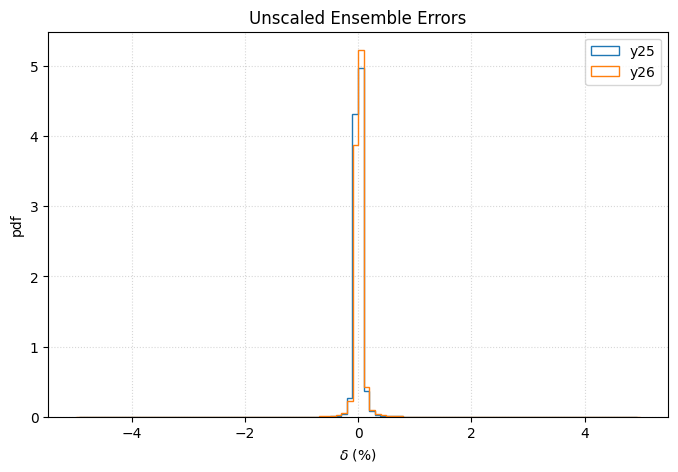

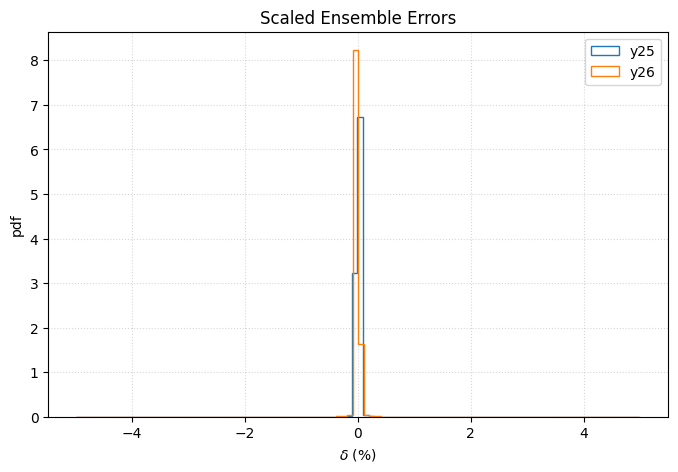

Completed all evaluations for pair y25y26


In [27]:
# all_results[pair]["ensemble"] = run_ensemble_evaluation(
#     test_df=filtered_test_df,
#     checkpoint_paths=pair_checkpoint_paths,
#     config=pair_config,
#     dataloader=pair_test_loader,
#     eps=0,
# )
# print(f"Completed all evaluations for pair {pair}")


In [28]:
# def ensemble_from_checkpoints_ort(onnx_paths, dataloader, config, eps=1e-6):
#     """
#     Ensemble evaluation using ORT inference.
#     onnx_paths: list of .onnx files, one per seed
#     """
#     providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
    
#     # load all sessions upfront
#     sessions = [ort.InferenceSession(p, providers=providers, sess_options=opts) for p in onnx_paths]
    
#     all_preds, all_targets = [], []
    
#     for xb, yb in dataloader:
#         x_np = xb.cpu().numpy()  # ORT needs numpy, not torch tensor
        
#         preds_per_ckpt = []
#         for sess in sessions:
#             pred = sess.run(None, {"input": x_np})[0]
#             preds_per_ckpt.append(pred)
        
#         mean_pred = np.mean(preds_per_ckpt, axis=0)
#         all_preds.append(mean_pred)
#         all_targets.append(yb.cpu().numpy())
    
#     y_true = np.vstack(all_targets)
#     y_pred = np.vstack(all_preds)
    
#     # rest is identical to your existing ensemble_from_checkpoints
#     y_names = config["var_y"]
#     y_unscale_vec = np.vectorize(y_unscale)
    
#     # scaled metrics
#     scaled = {}
#     overall_mape = safe_mape(y_true, y_pred, eps=eps)
#     overall_r2 = r2_score(y_true, y_pred)
#     overall_abs = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
#     scaled["overall"] = {"MAPE": overall_mape, "R2": overall_r2, "abs_score": overall_abs}
#     scaled["per_target"] = {}
#     for j, name in enumerate(y_names):
#         mape_j = safe_mape(y_true[:, j], y_pred[:, j], eps=eps)
#         r2_j = r2_score(y_true[:, j], y_pred[:, j])
#         abs_j = (1 - mape_j) * 100
#         scaled["per_target"][name] = {"MAPE": mape_j, "R2": r2_j, "abs_score": abs_j}

#     # unscaled metrics
#     y_true_un = y_unscale_vec(y_true)
#     y_pred_un = y_unscale_vec(y_pred)
#     unscaled = {}
#     overall_mape_un = safe_mape(y_true_un, y_pred_un, eps=eps)
#     overall_r2_un = r2_score(y_true_un, y_pred_un)
#     overall_abs_un = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
#     unscaled["overall"] = {"MAPE": overall_mape_un, "R2": overall_r2_un, "abs_score": overall_abs_un}
#     unscaled["per_target"] = {}
#     for j, name in enumerate(y_names):
#         mape_j_un = safe_mape(y_true_un[:, j], y_pred_un[:, j], eps=eps)
#         r2_j_un = r2_score(y_true_un[:, j], y_pred_un[:, j])
#         abs_j_un = (1 - mape_j_un) * 100
#         unscaled["per_target"][name] = {"MAPE": mape_j_un, "R2": r2_j_un, "abs_score": abs_j_un}

#     print("\n=== ORT Ensemble Evaluation (SCALED) ===")
#     print(f"Overall MAPE: {scaled['overall']['MAPE']:.6f}")
#     print(f"Overall R2  : {scaled['overall']['R2']:.6f}")
#     print(f"Overall Abs : {scaled['overall']['abs_score']:.6f}")

#     print("\n=== ORT Ensemble Evaluation (UNSCALED) ===")
#     print(f"Overall MAPE: {unscaled['overall']['MAPE']:.6f}")
#     print(f"Overall R2  : {unscaled['overall']['R2']:.6f}")
#     print(f"Overall Abs : {unscaled['overall']['abs_score']:.6f}")

#     return scaled, unscaled

# onnx_paths = [
#     os.path.join(ARTIFACT_ROOT, f"{pair}m{seed}", f"{pair}m{seed}.onnx")
#     for seed in MODEL_SEEDS
# ]

# scaled_ort, unscaled_ort = ensemble_from_checkpoints_ort(
#     onnx_paths=onnx_paths,
#     dataloader=pair_test_loader,
#     config=pair_config,
#     eps=0,
# )

/home/akula.ha/.conda/envs/myenv/lib/python3.9/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(



=== ORT Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.001065
Overall R2  : 0.999954
Overall Abs : 99.893481

=== ORT Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.001529
Overall R2  : 0.999924
Overall Abs : 99.847120


In [33]:
# import time

# def benchmark_torch_vs_ort(model, onnx_path, dataloader, n_runs=5):
#     device = get_device()
    
#     # ---- Torch ----
#     model.eval()
#     torch_times = []
#     for _ in tqdm(range(n_runs)):
#         start = time.perf_counter()
#         with torch.no_grad():
#             for xb, yb in dataloader:
#                 _ = model(xb)
#         torch_times.append(time.perf_counter() - start)
    
#     # ---- ORT ----
#     sess_options = ort.SessionOptions()
#     sess_options.intra_op_num_threads = 1
#     sess_options.inter_op_num_threads = 1
#     sess = ort.InferenceSession(onnx_path, sess_options=sess_options, providers=['GPUExecutionProvider'])
    
#     ort_times = []
#     for _ in tqdm(range(n_runs)):
#         start = time.perf_counter()
#         for xb, yb in dataloader:
#             _ = sess.run(None, {"input": xb.cpu().numpy()})
#         ort_times.append(time.perf_counter() - start)
    
#     print(f"Torch avg : {np.mean(torch_times):.3f}s ± {np.std(torch_times):.3f}s")
#     print(f"ORT avg   : {np.mean(ort_times):.3f}s ± {np.std(ort_times):.3f}s")
#     print(f"Speedup   : {np.mean(torch_times) / np.mean(ort_times):.2f}x")
    
#     return torch_times, ort_times

# onnx_path = os.path.join(ARTIFACT_ROOT, f"{pair}m1", f"{pair}m1.onnx")
# benchmark_torch_vs_ort(seed_model, onnx_path, pair_test_loader)

100%|██████████| 5/5 [01:03<00:00, 12.79s/it]
/home/akula.ha/.conda/envs/myenv/lib/python3.9/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'GPUExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


*************** EP Error ***************
EP Error Unknown Provider Type: GPUExecutionProvider when using ['GPUExecutionProvider']
Falling back to ['CPUExecutionProvider'] and retrying.
****************************************


100%|██████████| 5/5 [00:29<00:00,  5.86s/it]

Torch avg : 12.785s ± 2.814s
ORT avg   : 5.863s ± 0.197s
Speedup   : 2.18x


([14.096547067165375,
  13.88261804357171,
  8.867015533149242,
  16.715125557035208,
  10.362023871392012],
 [5.986247938126326,
  5.5841440334916115,
  5.829869747161865,
  5.754905004054308,
  6.158792205154896])

In [ ]:
# import onnx

In [26]:
# mlflow_tracking_helper(seed_config, model_uuid, output_dir, seed_model, eval_out, pair_test_loader)


Starting MLflow...


2026/04/02 23:55:01 INFO mlflow.utils.credentials: Successfully connected to MLflow hosted tracking server! Host: https://dbc-d0177b72-9a40.cloud.databricks.com.


MLflow login successful.
Uploading run data to MLflow...


/tmp/ipykernel_2279828/1527482068.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(latest_ckpt_path, map_location="cpu")


🏃 View run y25y26m1 at: https://dbc-d0177b72-9a40.cloud.databricks.com/ml/experiments/2404352143722631/runs/f83d8c103252488d8b5fe477726b1c9a
🧪 View experiment at: https://dbc-d0177b72-9a40.cloud.databricks.com/ml/experiments/2404352143722631
MLflow upload successful.

